In [5]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import cartopy.crs as ccrs

In [6]:
from dask.distributed import Client, LocalCluster 
cluster = LocalCluster(n_workers=14, memory_limit="9GiB") 
c = Client(cluster)
c

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.08/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 34007 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/34007/status,
Dashboard: /proxy/34007/status,Workers: 14
Total threads: 14,Total memory: 126.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35007,Workers: 0
Dashboard: /proxy/34007/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:37083,Total threads: 1
Dashboard: /proxy/34445/status,Memory: 9.00 GiB
Nanny: tcp://127.0.0.1:39375,


In [7]:
yyyy = 2018
mm = '04'
fnameu100m = '/g/data/ob53/BARRA2/output/reanalysis/AUST-04/BOM/ERA5/historical/hres/BARRA-C2/v1/1hr/ua100m/v20250528/ua100m_AUST-04_ERA5_historical_hres_BOM_BARRA-C2_v1_1hr_'+str(yyyy)+mm+'*.nc'
fnamev100m = '/g/data/ob53/BARRA2/output/reanalysis/AUST-04/BOM/ERA5/historical/hres/BARRA-C2/v1/1hr/va100m/v20250528/va100m_AUST-04_ERA5_historical_hres_BOM_BARRA-C2_v1_1hr_'+str(yyyy)+mm+'*.nc'

In [8]:
from functools import partial
def _preprocess(x, lon_min, lon_max, lat_min, lat_max):
    return x.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))

# Minimal example - enter what ever your spatial boundaries are here
lon_min = 135
lon_max = 155
lat_min = -40
lat_max = -30
partial_func = partial(_preprocess, lon_min = lon_min, lon_max=lon_max, lat_min = lat_min, lat_max = lat_max) 

In [9]:
u100m = xr.open_mfdataset(fnameu100m, preprocess=partial_func, combine='nested', concat_dim='time')
v100m = xr.open_mfdataset(fnamev100m, preprocess=partial_func, combine='nested', concat_dim='time')

In [10]:
spd = np.sqrt(u100m['ua100m']**2 + v100m['va100m']**2).load()

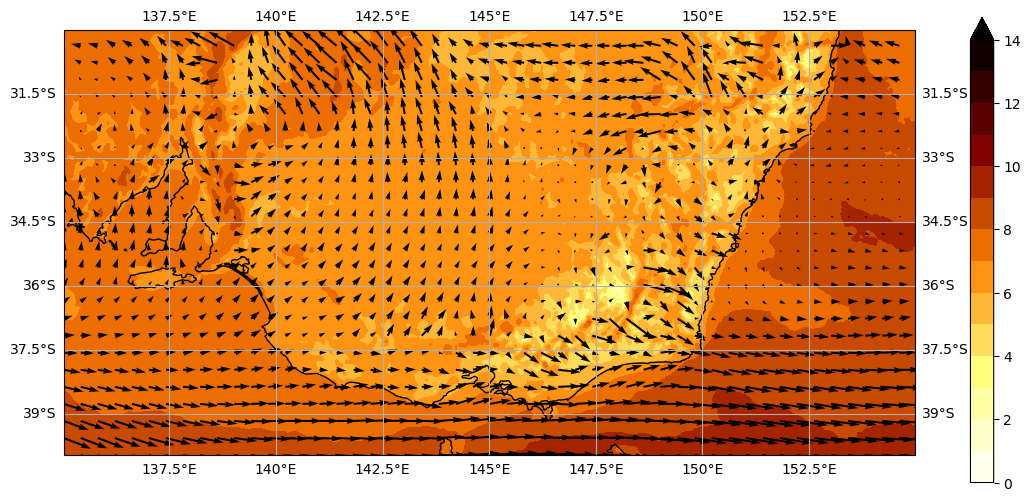

In [15]:
# Plot, just so you know what you're looking at:
plt.figure(figsize=(12, 10))
levels = np.arange(0,15,1)
src = ccrs.PlateCarree()
ax = plt.axes(projection=ccrs.PlateCarree())

iint = 10 # Spacing of quivers

ch = ax.contourf(u100m.lon, u100m.lat, spd[:,:,:].mean(dim='time'), levels=levels, extend='max', cmap='afmhot_r')
qh1 = ax.quiver(u100m.lon[::iint], u100m.lat[::iint], u100m.ua100m[:,::iint,::iint].mean(dim='time'), v100m.va100m[:,::iint,::iint].mean(dim='time'))

ax.coastlines(resolution='10m')
ax.gridlines(draw_labels=True)
plt.colorbar(ch, fraction=0.025, pad=0.06)

In [16]:
c.close()
c.shutdown()